<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Document_Processing_with_PaddleOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dcument Processing with PaddleOCR

In [1]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

In [2]:
# You need to install paddlepaddle superatedly appart from paddlleocr othe
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

In [3]:
# Make import superately make sure the version matches
from paddleocr import PaddleOCR

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import AgentExecutor
import csv

In [5]:
import os
from dotenv import load_dotenv
# Load environment variable from .env
_ = load_dotenv(override=True)

## 1. PaddleOCR Basic

In [6]:
# Initialize english OCR model
ocr = PaddleOCR(lang='en')

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached f

In [ ]:
from IPython.display import display

image_path = 'noisy_img.jpeg'
img = Image.open(image_path)
display(img)

In [7]:
import paddleocr
import paddle

In [8]:
print("paddleocr version: ", paddleocr.__version__)
print("paddle version: ", paddle.__version__)


paddleocr version:  3.3.3
paddle version:  3.2.0


In [ ]:
# Run OCR
result = ocr.predict(image_path)

In [ ]:
page = result[0]
texts = page['rec_texts'] # recognized text strings
scores = page['rec_scores'] # confidence scores for each text line
boxes = page['rec_polys'] # bounding box coordinates

for text, score, box in zip(texts, scores, boxes): # zip -> ties together items with the same position
  # box is a numpy array
  coords = box.astype(int).tolist() # convert to normal list of ints
  print(f"{text:25} | {score:.3f} | {coords}")

In [ ]:
# Preproccess the image
img = page['doc_preprocessor_res']['output_img']

In [ ]:
# display preprocessed image with all items overlayed
img_plot = img.copy()
for text, box in zip(texts, boxes):
  pts = np.array(box, dtype=int)
  cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
  x, y = pts[0]
  cv2.putText(img_plot, text, (x, y-5),
              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (processed Image) \n Rcognized text on the top")
plt.show()

## 1.1 Create the PaddleOCR Tool
Turn PaddleOCR to a tool so that can be used with an agent

In [9]:
from langchain.tools import tool
import base64
from langchain_openai import ChatOpenAI
from typing import List, Dict, Any

@tool
def paddle_ocr_read_document(image_path: str) -> List[Dict[str, Any]]:
  """
  Reads an image from the given path and returns extracted text
  with bounding boxes.

  Returns a list of dictionaries, each containing:
  - 'text': the recognized text string
  - 'bbox': bounding box coordinates [x_min, y_min, x_max, y_max]
  - 'confidence': recognition confidence score (if available)
  """
  try:
    result = ocr.predict(image_path) # from paddleOCR
    page = result[0]

    texts = page['rec_texts']
    boxes = page['dt_polys']
    scores = page.get('rec_scores', [None] * len(texts))

    extracted_items = []
    for text, box, score in zip(texts, boxes, scores):
      x_coords = [point[0] for point in box]
      y_coords = [point[1] for point in box]
      bbox = [min(x_coords), min(y_coords), max(x_coords),
              max(y_coords)]

      item = {
          'text': text,
          'bbox': bbox
      }

      if score is not None:
        item['confidance'] = score
      extracted_items.append(item)
    return extracted_items
  except Exception as e:
    return [{'error': f'Error reading image {e}'}]

## 1.2 Create & Run the Agent


In [ ]:
# 1. Define the list of tools
tools = [paddle_ocr_read_document]

# 2. Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=1
    )
    print("OpenAI Chat model initialized.")

In [ ]:
from langchain.agents import create_tool_calling_agent
# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant designed to extract information "+
        "from documents. "
          "You have access to this tool: "
          "Paddle OCR tool to extract raw texts, bounding boxes for "+
          "each text and confidence score from images "
    ),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name='agent_scratchpad'),
])

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:
# Run the agent and extract information
task = """
Process the document at 'noisy_img.jpeg' and evaluate that
the total amount is correct.
"""

response = agent_executor.invoke({"input": task})

## 1.3. Run PaddleOCR on the Table and Handwriting examples

In [ ]:
def run_ocr(image_path, ocr_model=ocr, show_text=True):
  display(Image.open(image_path))
  result = ocr.predict(image_path) # result from paddleOCR

  page = result[0]
  texts = page['rec_texts']
  scores = page['rec_scores']
  boxes = page['rec_polys']

  for text, score, box in zip(texts, scores, boxes):
    coords = box.astype(int).tolist()
    print(f'{text:25} | {score:.3f} | {coords}')

  # post proccessed image
  img = page['doc_preprocessor_res']['output_img']
  img_plot = img.copy()

  image_path = Path(image_path)
  output_path = image_path.with_stem(image_path.stem + '_output')
  cv2.imwrite(str(output_path), img, [cv2.IMWRITE_JPEG_QUALITY, 70])

  # Make some annotation on top using bounding box cordinate
  for text, box in zip(texts, boxes):
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    x, y = pts[0]
    if show_text:
      cv2.putText(img_plot, text,
                  (x, y-5), cv2.FONT_HERSHEY_SIMPLEX,
                  1.0, (255, 0, 0), 2)

  plt.figure(figsize=(10, 12))
  plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_RGB2RGBA))
  plt.axis('off')

In [ ]:
# image source: https://www.nature.com/articles/s41597-024-03605-5/figures/4
run_ocr('open-ai-rate-limit.png')

In [ ]:
task = """
This is the OpenAI rate limit table. I am only using it for extracting text from images and chat with the extracted text
information from the image. My daily usage is between 5 to 10 hit now please process the document at 'open-ai-rate-limit.png'
and tell me which model is the best I can use to avoid an extra payment.
"""

response = agent_executor.invoke({'input': task})

# Display results side by side
print('\n' + '_'*35 + 'LLM RESULT ' + '_'*33)
print("="*80)
print(response['output'])
print('='*80)

## Extract topics from past exam paper

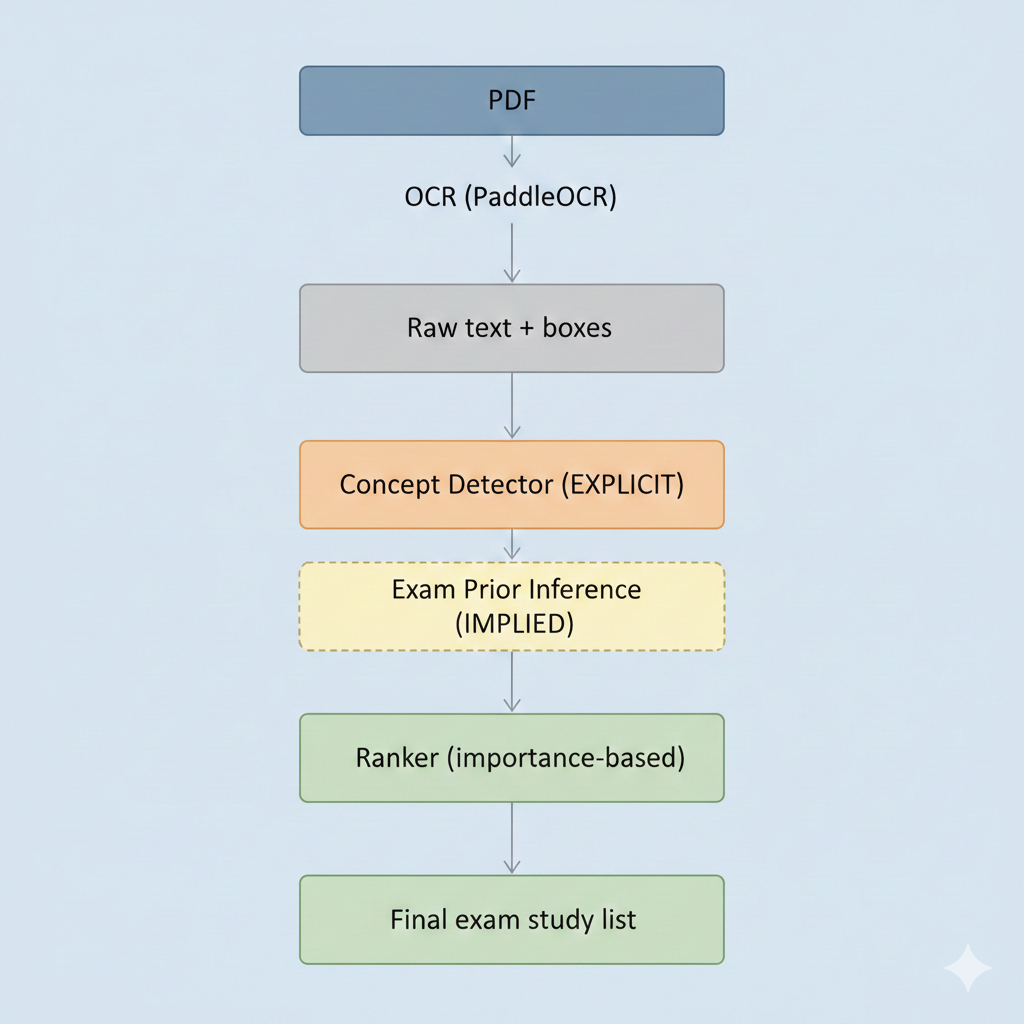

Create a tool

In [9]:
from langchain.tools import tool
import base64
from langchain_openai import ChatOpenAI
from typing import List, Dict, Any
from IPython.display import display


@tool
def paddle_ocr_read_document_pdf(doc_path: str) -> List[Dict[str, Any]]:
  """
  Reads a document from the given path and returns the extracted text
  """
  try:
    result = ocr.predict(doc_path) # from paddleOCR
    page = result[0]

    texts = page['rec_texts']
    scores = page.get('rec_scores', [None]*len(texts))

    return {
        "full_text": "\n".join(texts),
        "texts": texts,
        "scores": scores
    }
  except Exception as e:
     return { "error": f"Error reading document: {str(e)}" }

In [10]:
# 1. Define the list of tools
tools = [paddle_ocr_read_document_pdf]

# 2. Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=1
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


System prompt for the examp paper text extraction agen

In [11]:
from langchain.agents import create_tool_calling_agent
# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", """
        You are an expert university professor and exam designer in Signal and Image Processing.

        You have access to OCR tool that returns raw extracted text.

        RULES:
        1. Only use the OCR output as EXPLICIT facts.
        2. You MAY infer concepts ONLY if they are universally implied by the text.
        3. All inferred concepts must be marked with [IMPLIED].
        4. Do NOT invent unrelated concepts.
        5. Output ONE ordered list ONLY.
        6. Rank from most important to least important.

        Output example:
        1. Aliasing
        2. Sampling theorem [IMPLIED]
        3. Quantization error
    """),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name='agent_scratchpad'),
])

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

In [12]:
# Run the agent and extract information
task = """
Process the document at path: exam_example_pt1.pdf

1. Use OCR tool.
2. Extract explicit exam concepts.
3. Add implied concepts only when necessary.
4. Mark implied concepts with [IMPLIED].
5. Output ONE ordered list only.
"""

response = agent_executor.invoke({"input": task})

In [13]:
response['output'].split('\n')

['1. ADC',
 '2. Quantization error',
 '3. Aliasing',
 '4. Offset',
 '5. Gain',
 '6. Non linearity',
 '7. Missing code',
 '8. Hamming windows',
 '9. Periodic signal (x(t + T0) = x(t))',
 '10. Fundamental period / smallest repetition interval T0',
 '11. Digital frequency',
 '12. Candidate units for digital frequency: radians/seconds; radians; seconds',
 '13. Signal x(t) = 20 cos(2π(40)t − 0.4π)',
 '14. Amplitude = 20',
 '15. Frequency = 40 [IMPLIED]',
 '16. Phase = −0.4π [IMPLIED]',
 '17. Cosine wave (plot recognition)',
 '18. Time axis (Time (s))']

2nd LLM pass: infer implied concepts (ONLY from OCR output)

In [14]:
from langchain.schema import HumanMessage

In [15]:

ocr_text = response["output"]

inference_prompt = f"""
You are an expert exam designer.

You have the following OCR-extracted text from a document:

{ocr_text}

Task:
1. Extract explicit exam concepts (already in text).
2. Infer ONLY concepts that are universally implied.
3. Mark inferred concepts as [IMPLIED].
4. Output ONE ordered list ONLY.
5. Rank from most important to least important.
"""


final_response = llm([HumanMessage(content=inference_prompt)])

/tmp/ipython-input-77863811.py:19: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  final_response = llm([HumanMessage(content=inference_prompt)])


In [16]:
final_response.content.split('\n')

['1. ADC',
 '2. Sampling rate / sampling frequency fs [IMPLIED]',
 '3. Nyquist frequency / sampling theorem (sampling > 2·fmax to avoid aliasing) [IMPLIED]',
 '4. Aliasing',
 '5. Anti-aliasing (analog low-pass) filter before ADC [IMPLIED]',
 '6. Quantization error',
 '7. Quantization resolution / number of bits / quantization levels [IMPLIED]',
 '8. Signal-to-quantization-noise ratio (SQNR) / effect of bits on SNR [IMPLIED]',
 '9. Offset',
 '10. Gain',
 '11. Non linearity',
 '12. Differential and integral nonlinearity (DNL / INL) as specific nonlinearity measures [IMPLIED]',
 '13. Missing code',
 '14. Hamming windows',
 '15. Purpose of windowing / spectral leakage reduction (why Hamming window is used) [IMPLIED]',
 '16. Periodic signal (x(t + T0) = x(t))',
 '17. Fundamental period / smallest repetition interval T0',
 '18. Fundamental frequency f0 = 1 / T0 [IMPLIED]',
 '19. Digital frequency',
 '20. Common digital-frequency units and normalization (radians/sample, cycles/sample, Hz conv

In [17]:
response['output'].split('\n')

['1. ADC',
 '2. Quantization error',
 '3. Aliasing',
 '4. Offset',
 '5. Gain',
 '6. Non linearity',
 '7. Missing code',
 '8. Hamming windows',
 '9. Periodic signal (x(t + T0) = x(t))',
 '10. Fundamental period / smallest repetition interval T0',
 '11. Digital frequency',
 '12. Candidate units for digital frequency: radians/seconds; radians; seconds',
 '13. Signal x(t) = 20 cos(2π(40)t − 0.4π)',
 '14. Amplitude = 20',
 '15. Frequency = 40 [IMPLIED]',
 '16. Phase = −0.4π [IMPLIED]',
 '17. Cosine wave (plot recognition)',
 '18. Time axis (Time (s))']